In [1]:
import pandas as pd
import numpy as  np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.metrics import classification_report, roc_curve, roc_auc_score
from sklearn.tree import plot_tree

In [2]:
df = pd.read_csv("D:\DEV VELLY\Datasets\diabetes.csv")
df = df.drop(index = 0)
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\HASEEB\AppData\Local\Temp\ipykernel_17444\826612229.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("D:\DEV VELLY\Datasets\diabetes.csv")


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0


In [3]:
df.shape

(767, 9)

In [4]:
feature_cols = ['pregnet', 'insulin', 'bmi', 'age', 'glucose', 'bp', 'pedigree']
X = df.drop('Outcome', axis = 1)
y = df['Outcome']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.25,random_state=42)

In [6]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [7]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[98, 26],
       [21, 47]])

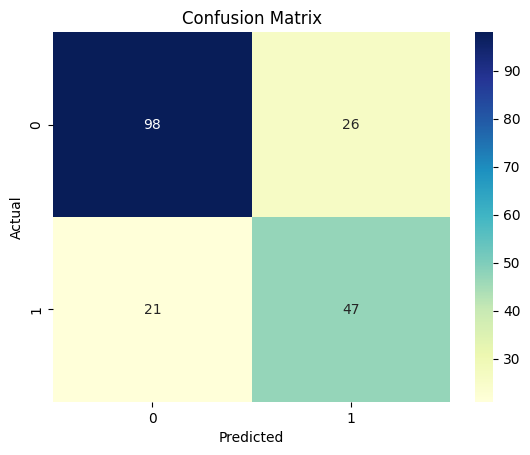

In [8]:
class_names = [0, 1]

plt.Figure(figsize= (6, 5))
sns.heatmap(cnf_matrix, annot = True, fmt = 'g', cmap = 'YlGnBu')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [9]:
y.value_counts()

Outcome
0    500
1    267
Name: count, dtype: int64

In [10]:
target_names = ['No Diabetes', 'Diabetes']
print(classification_report(y_test, y_pred, target_names = target_names))

              precision    recall  f1-score   support

 No Diabetes       0.82      0.79      0.81       124
    Diabetes       0.64      0.69      0.67        68

    accuracy                           0.76       192
   macro avg       0.73      0.74      0.74       192
weighted avg       0.76      0.76      0.76       192



In [11]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.7552083333333334


In [12]:
y_prob = clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_prob)
auc_score = metrics.roc_auc_score(y_test, y_prob)

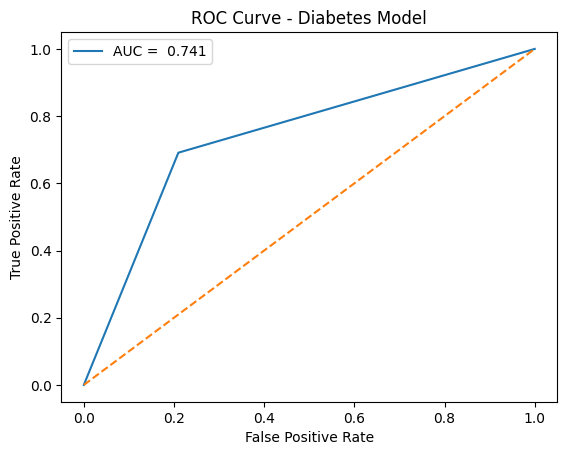

In [13]:
plt.figure()
plt.plot(fpr, tpr, label = f"AUC = {auc_score: .3f}")
plt.plot([0, 1], [0, 1], linestyle = '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Diabetes Model")
plt.legend()
plt.show()

In [14]:
print("Model features: ", clf.n_features_in_)
print("Your feature list: ", len(feature_cols))

Model features:  8
Your feature list:  7


In [15]:
feature_cols = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPefigreeFunction",
    "Age"
]

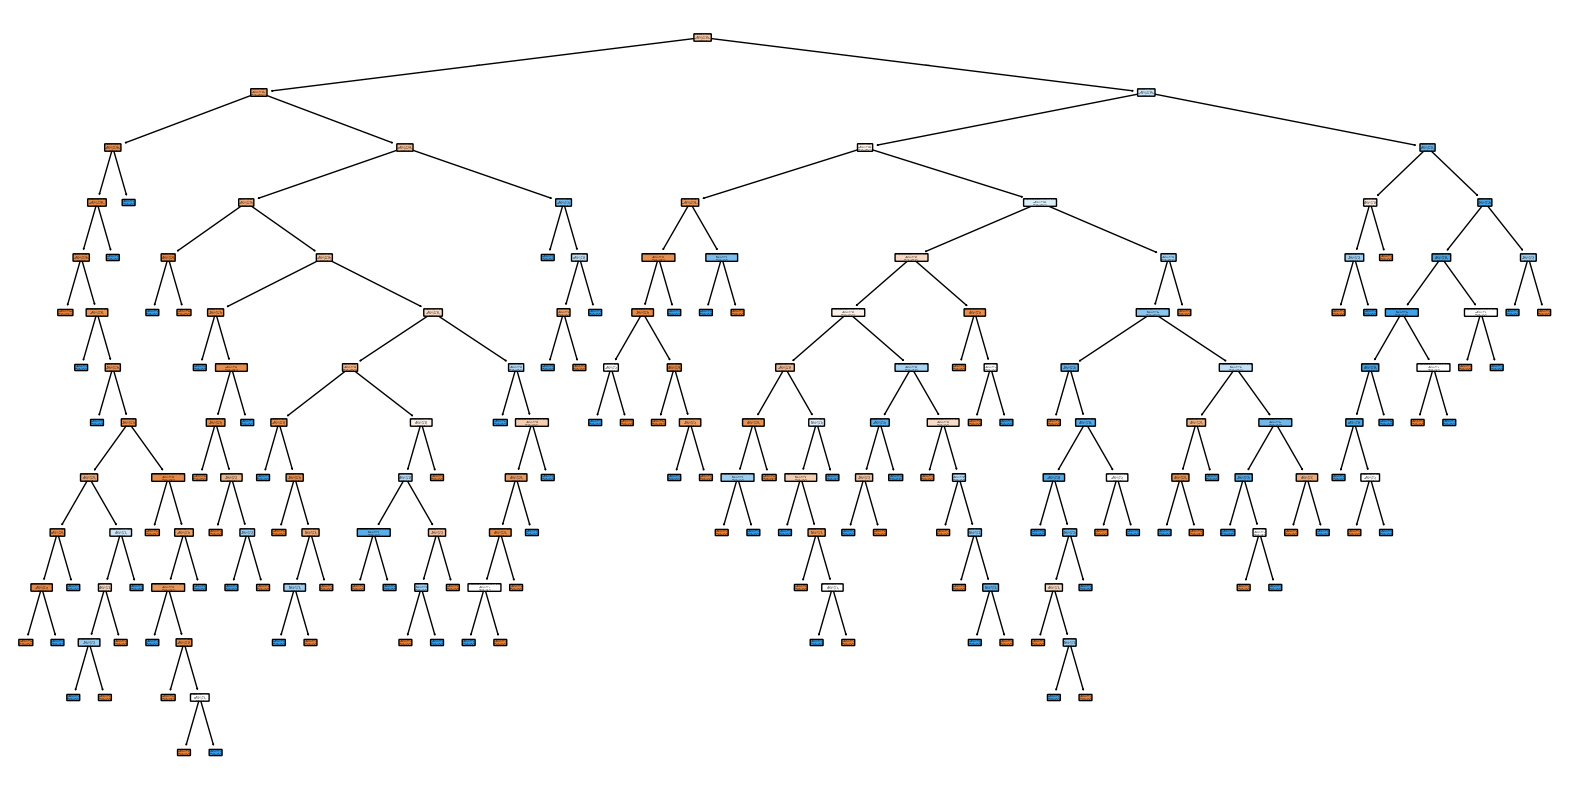

In [16]:
plt.figure(figsize=(20, 10))
plot_tree(
    clf,
    feature_names= feature_cols,
    class_names=[str(i) for i in clf.classes_],
    filled = True,
    rounded = True
)
plt.show()